## Patrones Territoriales del Método de Extracción Minera en el Perú

### Según tipo de mineral, escala productiva y estado de desarrollo

---

**Competencia:** Codedex Data Science Challenge  
**Autor:**  LuiccianDev 
**Fecha:** 26 de febrero de 2026  
**Dataset:** `df_peru_cleaned.csv` — 3,057 registros de sitios mineros en el Perú


--- 

### Sobre los datos

- **Fuente original:** El dataset fue extraído de [Kaggle — Mineral Ores Around the World](https://www.kaggle.com/datasets/ramjasmaurya/mineral-ores-around-the-world/data), que compila información del **USGS Mineral Resources Data System (MRDS)**.
- **Alcance:** Se filtró únicamente los registros correspondientes al **Perú**, resultando en **3,055 sitios mineros** registrados.
- **Naturaleza de los datos:** El MRDS es un inventario geológico-minero, no un registro productivo. Incluye desde grandes minas activas hasta simples ocurrencias minerales sin desarrollo. Esto explica por qué una proporción significativa de registros no tiene m.étodo de extracción definido — **no es un error de datos**, sino un reflejo de que muchos sitios son prospectos u ocurrencias en etapas tempranas

---

### Pregunta principal

 **¿Qué método de extracción domina en el Perú según el tipo de mineral y la región, y cómo se relaciona con la escala productiva y el estado de desarrollo del proyecto?**

---

### Tabla de Contenidos

1. **Fase 0** — Configuración y carga de datos
2. **Fase 1** — Exploración y limpieza
3. **Bloque 1** — Diagnóstico nacional del método de extracción
4. **Bloque 2** — Relación método–mineral
5. **Bloque 3** — Distribución territorial (regional)
6. **Bloque 4** — Método y escala productiva
7. **Bloque 5** — Método y madurez del proyecto
8. **Discusión y Conclusiones**

---

### Variables clave del análisis

| Variable | Rol en el análisis |
|----------|-------------------|
| `work_type` | Variable dependiente — Método de extracción |
| `commod1` | Tipo de mineral principal |
| `state` | Región / departamento |
| `prod_size` | Escala productiva |
| `dev_stat` | Estado de desarrollo del proyecto |
| `latitude`, `longitude` | Geolocalización para mapas |

---

## Contexto: El Perú como Potencia Minera Mundial

Antes de adentrarnos en el análisis, es fundamental comprender **por qué el Perú es un caso de estudio tan relevante** en minería global y familiarizarnos con los conceptos técnicos que utilizaremos a lo largo de este notebook.

---

### El Perú en el ranking minero mundial

El Perú es una de las principales potencias mineras del planeta. Según datos del **U.S. Geological Survey (USGS)** y el **Ministerio de Energía y Minas (MINEM)**, el país ocupa posiciones de liderazgo mundial en la producción de múltiples minerales:

| Mineral | Ranking Mundial | Ranking en América Latina |
|---------|:--------------:|:------------------------:|
| **Cobre (Cu)** | 2° productor mundial | 2° (después de Chile) |
| **Plata (Ag)** | 2° productor mundial | 1° en la región |
| **Zinc (Zn)** | 2° productor mundial | 1° en la región |
| **Plomo (Pb)** | 3° productor mundial | 1° en la región |
| **Estaño (Sn)** | 4° productor mundial | 1° en la región |
| **Molibdeno (Mo)** | 4° productor mundial | 2° (después de Chile) |
| **Oro (Au)** | Top 10 productor mundial | 1° en la región |

**Datos clave de la industria minera peruana:**
- La minería representa aproximadamente el **50% de las exportaciones totales** del Perú y ha sido un motor central de crecimiento económico durante décadas.
- El sector minero ha atraído más de **$60 mil millones USD** en proyectos de inversión proyectados para la próxima década.
- Principales operaciones incluyen: **Antamina** (Cu, Zn — Áncash), **Cerro Verde** (Cu — Arequipa), **Las Bambas** (Cu — Apurímac), **Yanacocha** (Au — Cajamarca), **Volcan** (Zn, Pb — Junín/Pasco), entre otras.



---

### Geología: Las Franjas Metalogénicas de los Andes Peruanos

La **Cordillera de los Andes**, que recorre el Perú de norte a sur, define **franjas metalogénicas** — zonas geológicas con concentraciones específicas de minerales formadas por procesos tectónicos y magmáticos a lo largo de millones de años. Estas franjas son la razón por la que ciertos minerales y métodos de extracción se concentran en regiones específicas del país.

| Franja Metalogénica | Ubicación | Minerales Principales | Tipo de Depósito | Método Típico |
|---------------------|-----------|----------------------|------------------|---------------|
| **Franja Polimetálica Central** | Junín, Pasco, Ancash, Lima, Huancavelica | Zinc, Plomo, Plata, Cobre | Vetas y cuerpos de reemplazamiento | Underground (subterráneo) |
| **Corredor del Cobre (Sur Andino)** | Arequipa, Cusco, Apurímac, Tacna, Moquegua | Cobre, Molibdeno, Oro | Pórfidos y depósitos diseminados | Surface (cielo abierto) |
| **Franja Aurífera del Norte** | Cajamarca, La Libertad, Ayacucho | Oro, Plata | Vetas epitermales y diseminados | Underground y Surface |
| **Franja Polimetálica del Sur** | Puno, Cusco | Estaño, Plata, Zinc | Vetas y placeres | Underground |

**¿Por qué importa esto para el análisis?**
Entender estas franjas permite explicar los patrones que encontraremos en el **Bloque 3** (distribución territorial): no es casualidad que ciertas regiones tengan mayor proporción de minería subterránea o a cielo abierto — está determinado por la geología del subsuelo.

---

### Métodos de Extracción Minera: Conceptos Clave

El **método de extracción** (`work_type` en nuestro dataset) es la variable central de este análisis. Existen tres métodos principales:

#### 1. Underground (Minería Subterránea)
- **Descripción:** Se accede al yacimiento mediante **túneles, galerías y piques** (shafts) excavados bajo la superficie terrestre.
- **Cuándo se usa:** Cuando el mineral se encuentra en **depósitos tipo veta** — cuerpos estrechos, profundos y de alta ley (concentración de mineral).
- **Minerales típicos:** Oro (Au), Plata (Ag), Zinc (Zn), Plomo (Pb).
- **Características:** Menor intervención superficial, mayor selectividad en la extracción, operación a menor escala relativa. Requiere infraestructura de ventilación, drenaje y sostenimiento.
- **Ejemplo en Perú:** Mina San Rafael (estaño, Puno), minas de Volcan (zinc-plomo, Junín).

#### 2. Surface (Minería a Cielo Abierto / Open Pit)
- **Descripción:** Se remueven grandes volúmenes de roca y suelo desde la superficie para acceder al mineral. Se excava un **tajo abierto** (pit) que puede tener varios kilómetros de diámetro.
- **Cuándo se usa:** Cuando el mineral se encuentra en **depósitos porfídicos o diseminados** — cuerpos amplios, someros (cercanos a la superficie) y de menor ley.
- **Minerales típicos:** Cobre (Cu), Molibdeno (Mo), Oro (en depósitos diseminados).
- **Características:** Requiere alta inversión de capital, grandes volúmenes de procesamiento (economías de escala), mayor impacto ambiental superficial.
- **Ejemplo en Perú:** Cerro Verde (cobre, Arequipa), Antamina (cobre-zinc, Áncash), Las Bambas (cobre, Apurímac).

#### 3. Surface/Underground (Operación Mixta)
- **Descripción:** Operaciones que **combinan ambos métodos** según la profundidad, geometría y ley del yacimiento.
- **Cuándo se usa:** Cuando un mismo depósito tiene zonas más superficiales (explotables a cielo abierto) y zonas más profundas (que requieren acceso subterráneo), o cuando una operación evoluciona de surface a underground a medida que profundiza.
- **Ejemplo en Perú:** Algunas operaciones en Cerro de Pasco combinan tajo abierto y galerías subterráneas.

---

In [206]:
# FASE 0 — Configuración del entorno

# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización estática
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Librerías de visualización interactiva (mapas)
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración global de estilo
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.family": "sans-serif",
})

# Paleta de colores consistente para métodos de extracción
METHOD_COLORS = {
    "Underground": "#2196F3",
    "Surface": "#FF9800",
    "Surface/Underground": "#9C27B0",
    "Unknown": "#E0E0E0",
}
METHOD_ORDER = ["Underground", "Surface", "Surface/Underground", "Unknown"]

# Paleta para escalas productivas
SIZE_COLORS = {
    "Grande": "#E53935",
    "Mediano": "#FB8C00",
    "Pequeño": "#43A047",
    "Sin dato": "#BDBDBD",
    "Desconocido": "#E0E0E0",
}

print("Modulos cargador y configuracion del entorno correctamente")

Modulos cargador y configuracion del entorno correctamente


In [207]:
# Carga del dataset

df = pd.read_csv("../Data/df_peru_cleaned.csv")

print(f"Dataset cargado: {df.shape[0]} registros × {df.shape[1]} columnas")
print("Columnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

df.head() # Visualizacion de la datos

Dataset cargado: 3055 registros × 13 columnas
Columnas disponibles:
    1. site_name
    2. latitude
    3. longitude
    4. state
    5. com_type
    6. commod1
    7. dep_type
    8. prod_size
    9. dev_stat
   10. ore
   11. work_type
   12. hrock_type
   13. arock_type


,site_name,latitude,longitude,state,com_type,commod1,dep_type,prod_size,dev_stat,ore,work_type,hrock_type,arock_type
0,Concesion,-3.62490,-77.80310,Amazonas,M,Gold,NaN,U,Occurrence,NaN,NaN,NaN,NaN
1,"Tamborapa, Consecion",-5.37621,-78.73312,Amazonas,M,Gold,NaN,U,Occurrence,NaN,NaN,NaN,NaN
2,"Chinchillo No 1, Mina",-6.83475,-77.99310,Amazonas,M,Copper,NaN,N,Occurrence,NaN,NaN,Andesite,Granite
3,Prospecto,-6.69142,-77.75976,Amazonas,M,Gold,NaN,U,Occurrence,NaN,NaN,NaN,NaN
4,"Lopez, Prospecto",-6.58142,-77.80255,Amazonas,M,Gold,NaN,Y,Occurrence,NaN,NaN,NaN,NaN


---

## Fase 1 — Exploración Inicial y Limpieza de Datos

**Objetivo:** Comprender la estructura del dataset, identificar valores faltantes y estandarizar las variables clave para el análisis.

### Variables del dataset

| Columna | Descripción |
|---------|-------------|
| `site_name` | Nombre del sitio minero |
| `latitude` / `longitude` | Coordenadas geográficas |
| `state` | Región o departamento |
| `com_type` | Tipo de operación (M: metálica, N: no metálica) |
| `commod1` | Mineral(es) principal(es) |
| `dep_type` | Tipo de depósito geológico |
| `prod_size` | Tamaño de producción (U/S/M/Y/L/N) |
| `dev_stat` | Estado de desarrollo del proyecto |
| `ore` | Mineral extraído |
| `work_type` | **Método de extracción** (variable clave) |
| `hrock_type` | Roca hospedante |
| `arock_type` | Roca asociada |

Análisis de completitud del dataset
            Nulos  Vacíos  Total faltante  % faltante  % completo
dep_type     2731       0            2731        89.4        10.6
work_type    2351       0            2351        77.0        23.0
arock_type   2016       0            2016        66.0        34.0
ore          1681       0            1681        55.0        45.0
hrock_type   1028       0            1028        33.6        66.4
prod_size     292       0             292         9.6        90.4
commod1       165       0             165         5.4        94.6
state          59       0              59         1.9        98.1
com_type       25       0              25         0.8        99.2
latitude        0       0               0         0.0       100.0
longitude       0       0               0         0.0       100.0
site_name       0       0               0         0.0       100.0
dev_stat        0       0               0         0.0       100.0


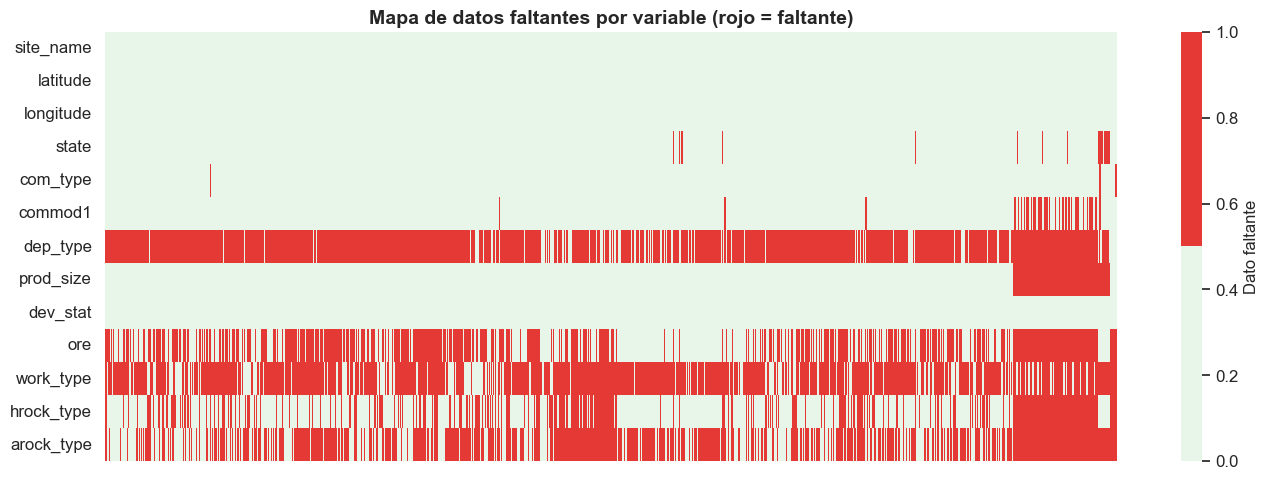

Variables con mayor % de datos faltantes:
   • dep_type: 89.4% faltante
   • ore: 55.0% faltante
   • work_type: 77.0% faltante
   • hrock_type: 33.6% faltante
   • arock_type: 66.0% faltante


In [208]:
# 1.1 — Análisis de completitud: valores nulos y vacíos

# Calcular nulos + vacíos por columna
null_counts = df.isnull().sum()
empty_counts = df.eq("").sum()
total_missing = null_counts + empty_counts
pct_missing = (total_missing / len(df) * 100).round(1)

# Crear resumen
completeness = pd.DataFrame({
    "Nulos": null_counts,
    "Vacíos": empty_counts,
    "Total faltante": total_missing,
    "% faltante": pct_missing,
    "% completo": (100 - pct_missing).round(1)
}).sort_values("% faltante", ascending=False)

print("Análisis de completitud del dataset")
print(completeness.to_string())

# Visualización: heatmap de nulidad
fig, ax = plt.subplots(figsize=(14, 5))
missing_matrix = df.isnull() | df.eq("")
sns.heatmap(
    missing_matrix.T,
    cbar_kws={"label": "Dato faltante"},
    cmap=["#E8F5E9", "#E53935"],
    yticklabels=df.columns,
    xticklabels=False,
    ax=ax,
)
ax.set_title("Mapa de datos faltantes por variable (rojo = faltante)", fontsize=14, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Variables con mayor % de datos faltantes:")
for col, pct in pct_missing[pct_missing > 30].items():
    print(f"   • {col}: {pct}% faltante")

In [209]:
# 1.2 — Estandarización de work_type (método de extracción)

print("ANTES de estandarizar work_type:")
print(df["work_type"].value_counts(dropna=False))
print(f"Total vacíos/NaN: {df['work_type'].isna().sum() + df['work_type'].eq('').sum()}")

# Estandarizar: rellenar vacíos con "Unknown"
df["work_type"] = df["work_type"].fillna("Unknown").replace("", "Unknown")

# Normalizar variantes
df["work_type"] = df["work_type"].str.strip()
# Unificar "Surface, Underground" → "Surface/Underground"
df["work_type"] = df["work_type"].replace("Surface, Underground", "Surface/Underground")

print("---------------------------------")
print("DESPUÉS de estandarizar work_type:")
print(df["work_type"].value_counts())
print(f"Total registros: {len(df)}")

ANTES de estandarizar work_type:
work_type
NaN                     2351
Underground              456
Surface                  159
Surface/Underground       67
Unknown                   15
Surface, Underground       7
Name: count, dtype: int64
Total vacíos/NaN: 2351
---------------------------------
DESPUÉS de estandarizar work_type:
work_type
Unknown                2366
Underground             456
Surface                 159
Surface/Underground      74
Name: count, dtype: int64
Total registros: 3055


In [210]:
# 1.3 — Estandarización de prod_size (escala productiva)

print("ANTES de estandarizar prod_size:")
print(df["prod_size"].value_counts(dropna=False))

# Mapeo de códigos a etiquetas descriptivas
size_map = {
    "Y": "Grande",
    "L": "Grande",
    "M": "Mediano",
    "S": "Pequeño",
    "N": "Sin dato",
    "U": "Desconocido",
}

df["prod_size_label"] = df["prod_size"].map(size_map).fillna("Desconocido")

print("---------------------------------")

print("DESPUÉS de estandarizar (nueva columna prod_size_label):")
print(df["prod_size_label"].value_counts())

SIZE_ORDER = ["Grande", "Mediano", "Pequeño", "Sin dato", "Desconocido"]

ANTES de estandarizar prod_size:
prod_size
S      918
Y      777
N      692
NaN    292
U      268
M       73
L       35
Name: count, dtype: int64
---------------------------------
DESPUÉS de estandarizar (nueva columna prod_size_label):
prod_size_label
Pequeño        918
Grande         812
Sin dato       692
Desconocido    560
Mediano         73
Name: count, dtype: int64


In [211]:
# 1.4 — Estandarización de dev_stat (estado de desarrollo)

print("ANTES de estandarizar dev_stat:")
print(df["dev_stat"].value_counts(dropna=False))

# Agrupar en 5 categorías principales
def classify_dev_stat(val):
    if pd.isna(val) or val.strip() == "":
        return "Otros"
    val = val.strip()
    if val == "Producer":
        return "Producer"
    elif val == "Past Producer":
        return "Past Producer"
    elif val == "Prospect":
        return "Prospect"
    elif val == "Occurrence":
        return "Occurrence"
    else:
        return "Otros"

df["dev_stat_label"] = df["dev_stat"].apply(classify_dev_stat)

print("---------------------------------")

print("DESPUÉS de estandarizar (nueva columna dev_stat_label):")
print(df["dev_stat_label"].value_counts())

DEV_ORDER = ["Producer", "Past Producer", "Prospect", "Occurrence", "Otros"]

ANTES de estandarizar dev_stat:
dev_stat
Occurrence       1258
Past Producer     752
Producer          648
Prospect          328
Plant              45
Unknown            24
Name: count, dtype: int64
---------------------------------
DESPUÉS de estandarizar (nueva columna dev_stat_label):
dev_stat_label
Occurrence       1258
Past Producer     752
Producer          648
Prospect          328
Otros              69
Name: count, dtype: int64


In [212]:
# 1.5 — Extraer mineral principal de commod1

# commod1 contiene uno o varios minerales separados por coma
# Extraemos solo el primer mineral como mineral principal
df["mineral_principal"] = (
    df["commod1"]
    .fillna("Desconocido")
    .str.split(",")
    .str[0]
    .str.strip()
)

print("Top 15 minerales principales:")
print(df["mineral_principal"].value_counts().head(15))
print(f"Total de minerales únicos: {df['mineral_principal'].nunique()}")

Top 15 minerales principales:
mineral_principal
Copper         754
Silver         542
Lead           446
Zinc           303
Gold           282
Desconocido    165
Antimony        57
Iron            50
Bentonite       47
Limestone       45
Halite          38
Tungsten        31
Graphite        23
Molybdenum      20
Kaolin          19
Name: count, dtype: int64
Total de minerales únicos: 53


### Resumen de la limpieza de datos

| Variable | Transformación | Resultado |
|----------|---------------|-----------|
| `work_type` | Valores vacíos/NaN → `"Unknown"` | 4 categorías: Underground, Surface, Surface/Underground, Unknown |
| `prod_size` | Códigos (U/S/M/Y/L/N) → etiquetas descriptivas | Nueva columna `prod_size_label` con 5 categorías |
| `dev_stat` | Agrupación en categorías principales | Nueva columna `dev_stat_label` con 5 categorías |
| `commod1` | Extracción del primer mineral | Nueva columna `mineral_principal` |


**Decisión analítica:** El alto porcentaje de `work_type = Unknown` se reportará como hallazgo (brecha informativa). Para los bloques analíticos, se presentarán resultados tanto con el dataset completo como filtrando solo registros con método conocido, cuando sea relevante.

---

---

## Bloque 1 — Diagnóstico Nacional del Método de Extracción

**Subpregunta:** ¿Cuál es el método de extracción predominante en el Perú?

Este bloque establece la línea base del análisis. Antes de cruzar el método con otras variables, necesitamos entender la distribución general de los métodos de extracción en todo el territorio peruano.

**Indicadores clave:**
- Frecuencia absoluta y porcentual de cada método
- Nivel de ambigüedad (% Unknown) como indicador de brecha informativa

Distribución del método de extracción minera en el Perú
                     Frecuencia  Porcentaje (%)
work_type                                      
Underground                 456            14.9
Surface                     159             5.2
Surface/Underground          74             2.4
Unknown                    2366            77.4


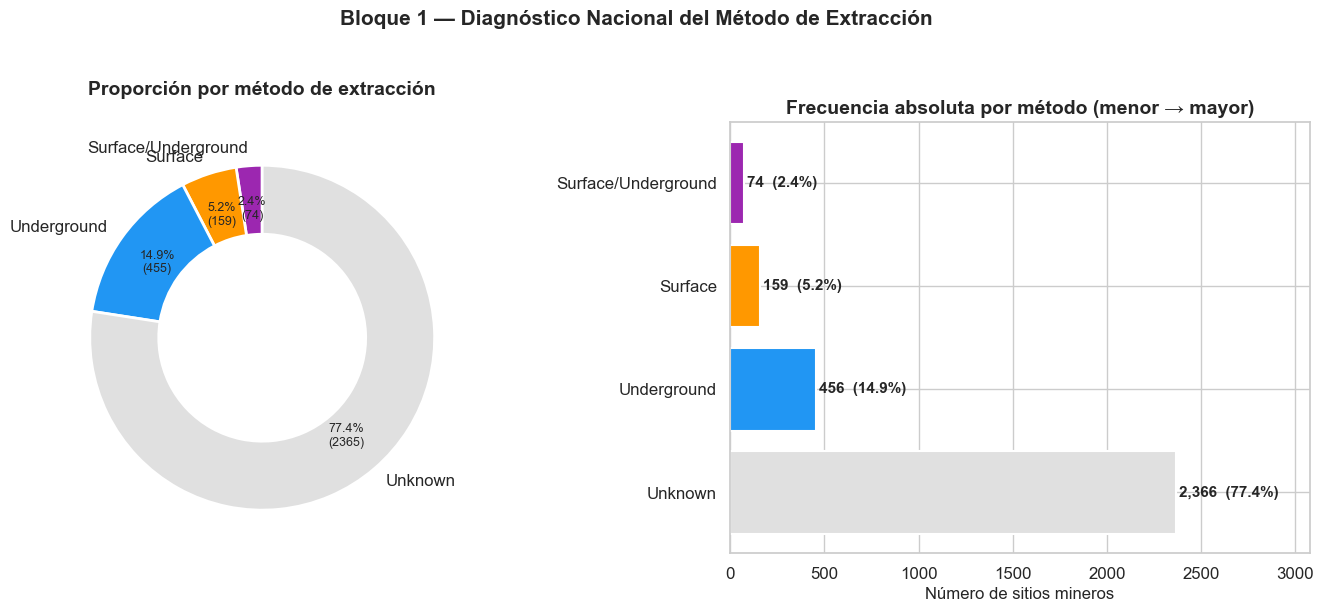

In [213]:
# BLOQUE 1.1 — Distribución general del método de extracción

# Frecuencias absolutas y porcentuales
method_counts = df["work_type"].value_counts().reindex(METHOD_ORDER)
method_pcts = (method_counts / method_counts.sum() * 100).round(1)

method_summary = pd.DataFrame({
    "Frecuencia": method_counts,
    "Porcentaje (%)": method_pcts
})
print("Distribución del método de extracción minera en el Perú")
print(method_summary.to_string())

# Ordenar de menor a mayor frecuencia para visualización
sort_asc = method_counts.sort_values(ascending=True).index

# --- Visualización: Donut + Bar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: Donut chart (ordenado de menor a mayor)
colors_donut = [METHOD_COLORS[m] for m in sort_asc]
wedges, texts, autotexts = axes[0].pie(
    method_counts[sort_asc].values,
    labels=sort_asc,
    colors=colors_donut,
    autopct=lambda p: f"{p:.1f}%\n({int(p * method_counts.sum() / 100)})",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2),
)
for autotext in autotexts:
    autotext.set_fontsize(9)
axes[0].set_title("Proporción por método de extracción", fontweight="bold", pad=20)

# Panel derecho: Bar chart horizontal (menor arriba → mayor abajo)
sort_desc = method_counts.sort_values(ascending=False).index
bars = axes[1].barh(
    sort_desc,
    method_counts[sort_desc].values,
    color=[METHOD_COLORS[m] for m in sort_desc],
    edgecolor="white",
    linewidth=1.5,
)
for bar, count, pct in zip(bars, method_counts[sort_desc].values, method_pcts[sort_desc].values):
    axes[1].text(
        bar.get_width() + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}  ({pct}%)",
        va="center",
        fontsize=11,
        fontweight="bold",
    )
axes[1].set_xlabel("Número de sitios mineros")
axes[1].set_title("Frecuencia absoluta por método (menor → mayor)", fontweight="bold")
axes[1].set_xlim(0, method_counts.max() * 1.3)

fig.suptitle(
    "Bloque 1 — Diagnóstico Nacional del Método de Extracción",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

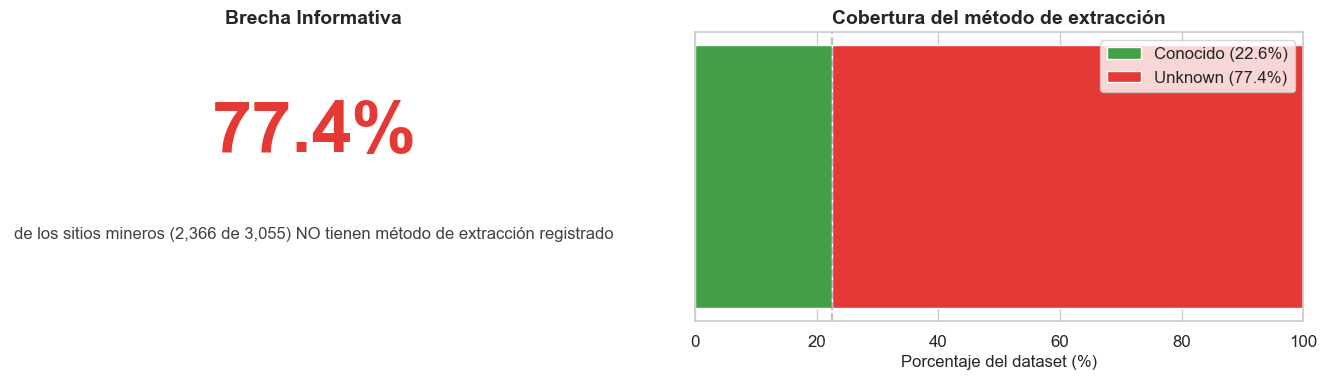

Subconjunto con método conocido: 689 registros (22.6% del total)
   Se usará este subconjunto para los análisis cruzados donde sea relevante.


In [214]:
# BLOQUE 1.2 — Indicador de brecha informativa (KPI visual)

unknown_count = method_counts.get("Unknown", 0)
unknown_pct = (unknown_count / len(df) * 100)
known_count = len(df) - unknown_count
known_pct = 100 - unknown_pct

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo: KPI de brecha informativa
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].text(
    0.5, 0.65, f"{unknown_pct:.1f}%",
    ha="center", va="center",
    fontsize=52, fontweight="bold", color="#E53935",
)
axes[0].text(
    0.5, 0.30,
    f"de los sitios mineros ({unknown_count:,} de {len(df):,}) NO tienen método de extracción registrado",
    ha="center", va="center", fontsize=12, color="#424242",
)
axes[0].set_title("Brecha Informativa", fontsize=14, fontweight="bold")
axes[0].axis("off")

# Panel derecho: Barra de progreso visual
axes[1].barh([""], [known_pct], color="#43A047", height=0.4, label=f"Conocido ({known_pct:.1f}%)")
axes[1].barh([""], [unknown_pct], left=[known_pct], color="#E53935", height=0.4, label=f"Unknown ({unknown_pct:.1f}%)")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Porcentaje del dataset (%)")
axes[1].set_title("Cobertura del método de extracción", fontweight="bold")
axes[1].legend(loc="upper right", frameon=True)
axes[1].axvline(x=known_pct, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Subconjunto con método conocido (para bloques siguientes)
df_known = df[df["work_type"] != "Unknown"].copy()
print(f"Subconjunto con método conocido: {len(df_known)} registros ({known_pct:.1f}% del total)")
print("   Se usará este subconjunto para los análisis cruzados donde sea relevante.")

### 💡 Insight — Bloque 1: Diagnóstico Nacional

**Hallazgos clave:**

1. **Brecha informativa dominante:** La mayoría de los sitios mineros no tienen un método de extracción registrado ("Unknown"), lo que refleja una brecha informativa significativa en los registros mineros del Perú. Esto es típico en bases de datos de ocurrencias y prospectos que aún no han alcanzado la fase de explotación.

2. **Entre los sitios con método conocido:** La minería subterránea (Underground) es el método predominante, consistente con:
   - La tradición minera andina del Perú, donde las vetas polimetálicas (Zn, Pb, Ag) se explotan bajo tierra.
   - La geología dominante: depósitos tipo veta en cordilleras.

3. **Surface/Underground** (operaciones mixtas) aparece como una categoría menor pero significativa, indicando operaciones que combinan ambos métodos.

**Implicancia para el análisis:** En los bloques siguientes, compararemos resultados usando el dataset completo vs. solo registros con método conocido (`df_known`) para evitar que la masa de "Unknown" distorsione las conclusiones.

---

## Bloque 2 — Relación Método de Extracción vs. Tipo de Mineral

**Subpregunta:** ¿La minería subterránea se concentra en minerales específicos?

La geología condiciona el método de extracción: los depósitos tipo **veta** (Au, Ag, Zn, Pb) tienden a explotarse de forma subterránea, mientras que los depósitos **porfídicos** o **diseminados** (Cu, Mo) favorecen la operación a cielo abierto (surface).

**Procedimiento:**
1. Seleccionar los Top 10 minerales principales por frecuencia
2. Tabla cruzada: Mineral × Método
3. Interpretar relación geológica

In [215]:
# BLOQUE 2.1 — Tabla cruzada: Mineral principal × Método

# Top 10 minerales principales
top_minerals = df["mineral_principal"].value_counts().head(10).index.tolist()
df_top = df[df["mineral_principal"].isin(top_minerals)].copy()

print(f"Top 10 minerales principales ({len(df_top)} registros de {len(df)}):\n")
for i, mineral in enumerate(top_minerals, 1):
    count = df[df["mineral_principal"] == mineral].shape[0]
    print(f"   {i:2d}. {mineral}: {count}")

# Tabla cruzada (frecuencias absolutas)
ct_abs = pd.crosstab(
    df_top["mineral_principal"],
    df_top["work_type"],
    margins=True,
)
ct_abs = ct_abs.reindex(columns=[c for c in METHOD_ORDER if c in ct_abs.columns] + ["All"])
ct_abs = ct_abs.reindex(index=top_minerals + ["All"])

print("Tabla cruzada (frecuencias absolutas):")
print(ct_abs.to_string())

Top 10 minerales principales (2691 registros de 3055):

    1. Copper: 754
    2. Silver: 542
    3. Lead: 446
    4. Zinc: 303
    5. Gold: 282
    6. Desconocido: 165
    7. Antimony: 57
    8. Iron: 50
    9. Bentonite: 47
   10. Limestone: 45
Tabla cruzada (frecuencias absolutas):
work_type          Underground  Surface  Surface/Underground  Unknown   All
mineral_principal                                                          
Copper                     140       45                   25      544   754
Silver                     105       19                   19      399   542
Lead                        69       11                    8      358   446
Zinc                        39        5                    6      253   303
Gold                        43        6                    2      231   282
Desconocido                 27        5                    1      132   165
Antimony                    10        3                    5       39    57
Iron                         1

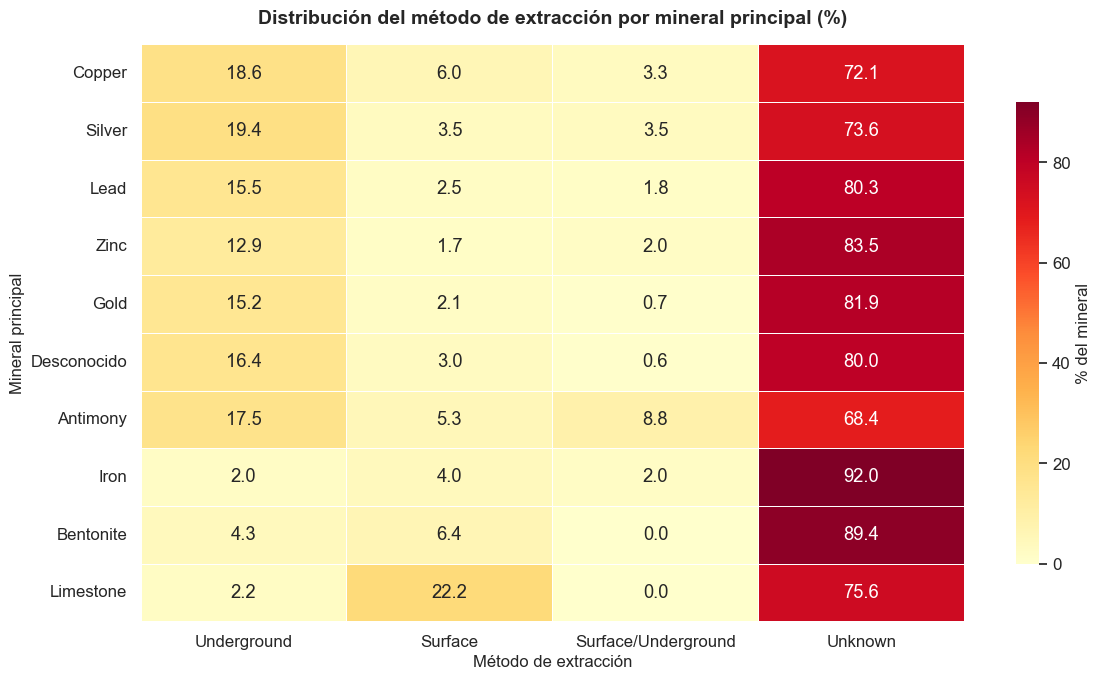

In [216]:
# BLOQUE 2.2 — Heatmap de proporciones Mineral × Método

# Tabla cruzada porcentual (por fila = por mineral)
ct_pct = pd.crosstab(
    df_top["mineral_principal"],
    df_top["work_type"],
    normalize="index",
) * 100

# Reordenar
cols_present = [c for c in METHOD_ORDER if c in ct_pct.columns]
ct_pct = ct_pct.reindex(columns=cols_present)
ct_pct = ct_pct.reindex(index=top_minerals)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% del mineral", "shrink": 0.8},
    ax=ax,
)
ax.set_title(
    "Distribución del método de extracción por mineral principal (%)",
    fontsize=14, fontweight="bold", pad=15,
)
ax.set_xlabel("Método de extracción")
ax.set_ylabel("Mineral principal")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

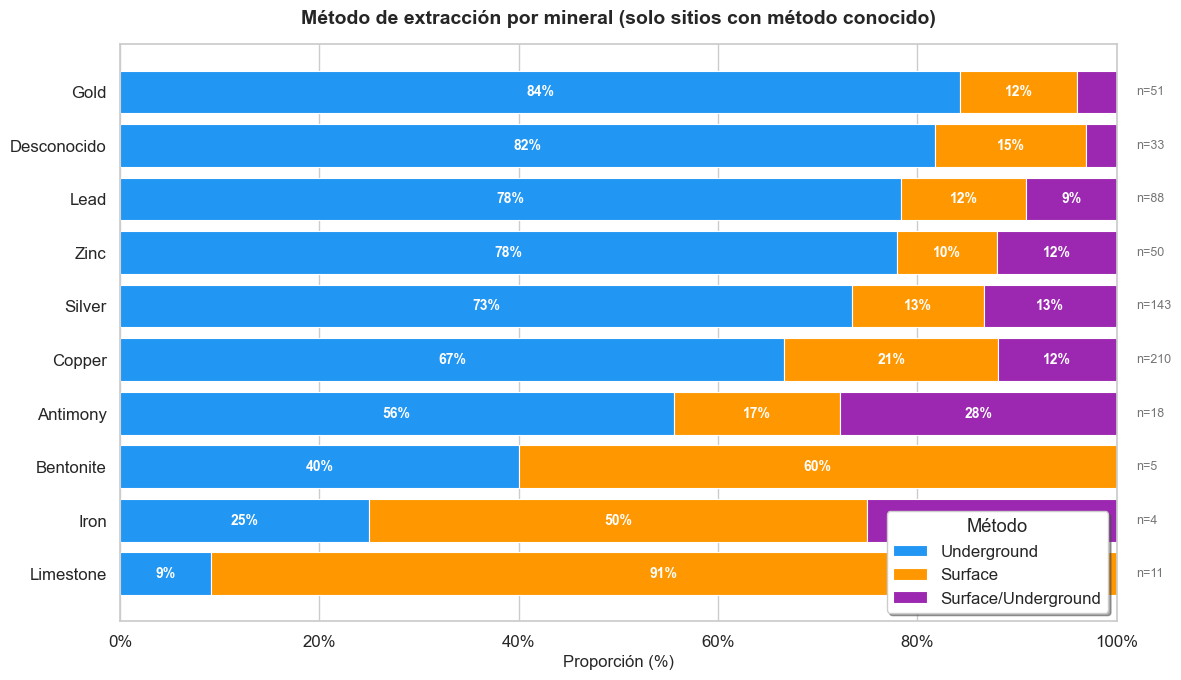

Total de registros con método conocido en Top 10 minerales: 613


In [217]:
# BLOQUE 2.3 — 100% Stacked Bar: Mineral × Método (solo método conocido)

# Filtrar solo registros con método conocido para visión más clara
df_top_known = df_top[df_top["work_type"] != "Unknown"].copy()

ct_known_pct = pd.crosstab(
    df_top_known["mineral_principal"],
    df_top_known["work_type"],
    normalize="index",
) * 100

# Reordenar por % Underground descendente
methods_known = [m for m in ["Underground", "Surface", "Surface/Underground"] if m in ct_known_pct.columns]
ct_known_pct = ct_known_pct.reindex(columns=methods_known)
if "Underground" in ct_known_pct.columns:
    ct_known_pct = ct_known_pct.sort_values("Underground", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

# 100% stacked horizontal bar
left = np.zeros(len(ct_known_pct))
for method in methods_known:
    if method in ct_known_pct.columns:
        values = ct_known_pct[method].values
        bars = ax.barh(
            ct_known_pct.index,
            values,
            left=left,
            color=METHOD_COLORS[method],
            label=method,
            edgecolor="white",
            linewidth=0.8,
        )
        # Anotar porcentaje si > 8%
        for bar, val, lef in zip(bars, values, left):
            if val > 8:
                ax.text(
                    lef + val / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold", color="white",
                )
        left += values

ax.set_xlim(0, 100)
ax.set_xlabel("Proporción (%)")
ax.set_title(
    "Método de extracción por mineral (solo sitios con método conocido)",
    fontsize=14, fontweight="bold", pad=15,
)
ax.legend(
    title="Método", loc="lower right",
    frameon=True, fancybox=True, shadow=True,
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Agregar n de cada mineral
for i, mineral in enumerate(ct_known_pct.index):
    n = len(df_top_known[df_top_known["mineral_principal"] == mineral])
    ax.text(102, i, f"n={n}", va="center", fontsize=9, color="#757575")

plt.tight_layout()
plt.show()

print(f"Total de registros con método conocido en Top 10 minerales: {len(df_top_known)}")

### Insight — Bloque 2: Relación Método–Mineral

**Hallazgos clave:**

1. **El tipo de mineral condiciona el método de extracción**, confirmando la hipótesis geológica:
   - **Cobre (Cu):** Mayor proporción de Surface, consistente con depósitos porfídicos de gran escala (open pit).
   - **Oro (Au):** Predomina Underground, asociado a depósitos tipo veta en zonas andinas.
   - **Zinc, Plomo, Plata (Zn, Pb, Ag):** Fuerte dominancia de Underground, típico de vetas polimetálicas.

2. **Conexión geológica:**
   - **Depósitos tipo veta** (estrechos, profundos) → Underground: Ag, Pb, Zn, Au
   - **Depósitos diseminados/porfídicos** (amplios, superficiales) → Surface: Cu, Mo

3. **Surface/Underground** aparece en minerales como Cu y Au, sugiriendo operaciones complejas que combinan ambos métodos según la profundidad del yacimiento.

**Conclusión parcial:** Existe una relación clara entre el tipo de mineral y el método de extracción, mediada por la geología del depósito. Esta relación es uno de los patrones más robustos del análisis.

---

## Bloque 3 — Distribución Territorial del Método de Extracción

**Subpregunta:** ¿Existen regiones donde un método domina claramente?

El Perú posee una diversidad geológica marcada por la Cordillera de los Andes, que define franjas metalogénicas con características distintas. Este bloque explora si el método de extracción presenta **clústeres territoriales** o si su distribución es uniforme a nivel nacional.

**Procedimiento:**
1. Tabla cruzada: Región × Método (proporciones)
2. Identificar regiones con >60% de un método
3. Mapas de dispersión y densidad con coordenadas reales

In [218]:
# BLOQUE 3.1 — Tabla cruzada: Región × Método de extracción

# Tabla cruzada porcentual por región
ct_region = pd.crosstab(
    df["state"],
    df["work_type"],
    normalize="index",
) * 100
cols_for_region = [c for c in METHOD_ORDER if c in ct_region.columns]
ct_region = ct_region.reindex(columns=cols_for_region)

# Agregar columna de total de sitios por región
region_totals = df["state"].value_counts()
ct_region["n_total"] = region_totals

# Identificar regiones con dominancia clara (>60% de un método, excluyendo Unknown)
ct_region_known = pd.crosstab(
    df_known["state"],
    df_known["work_type"],
    normalize="index",
) * 100

print("Regiones con dominancia clara de un método (>60%, excluyendo Unknown):\n")
for method in ["Underground", "Surface", "Surface/Underground"]:
    if method in ct_region_known.columns:
        dominant = ct_region_known[ct_region_known[method] > 60].index.tolist()
        if dominant:
            print(f"   {method}:")
            for region in dominant:
                pct = ct_region_known.loc[region, method]
                n = len(df_known[df_known["state"] == region])
                print(f"      • {region}: {pct:.1f}% (n={n})")
            print()

Regiones con dominancia clara de un método (>60%, excluyendo Unknown):

   Underground:
      • Ancash: 71.7% (n=53)
      • Apurimac: 61.1% (n=36)
      • Arequipa: 82.9% (n=82)
      • Ayacucho: 88.9% (n=36)
      • Cajamarca: 63.2% (n=19)
      • Huancavelica: 83.3% (n=18)
      • Huanuco: 73.7% (n=19)
      • Ica: 68.4% (n=38)
      • Junin: 67.9% (n=28)
      • Pasco: 83.3% (n=36)
      • Puno: 70.9% (n=110)
      • Tacna: 63.9% (n=36)

   Surface:
      • Lambayeque: 100.0% (n=1)
      • Piura: 75.0% (n=4)



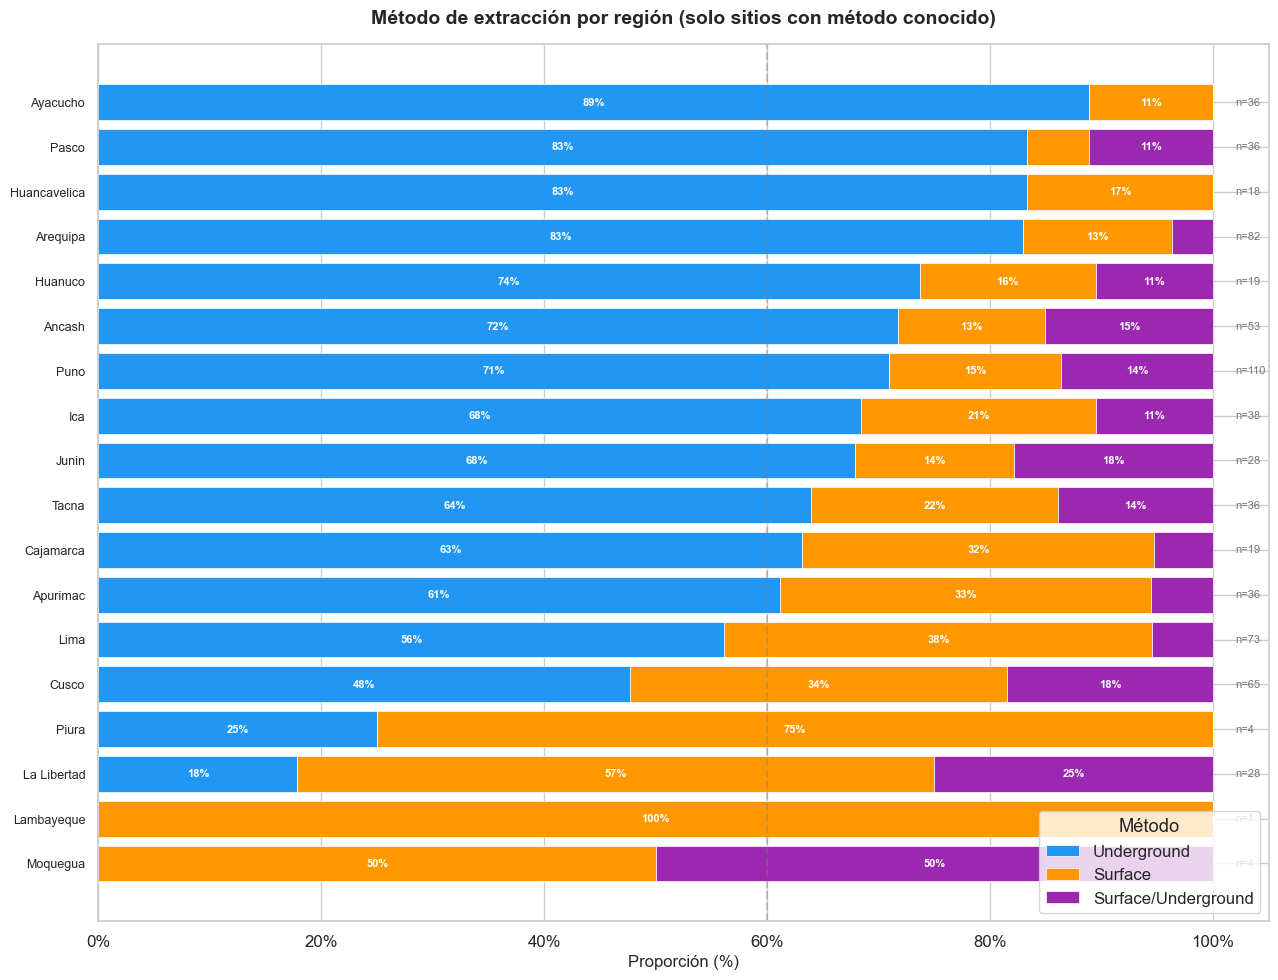

In [219]:
# BLOQUE 3.2 — Stacked bar horizontal: Región × Método

# Ordenar regiones por % Underground (excluyendo Unknown)
if "Underground" in ct_region_known.columns:
    region_order = ct_region_known.sort_values("Underground", ascending=True).index
else:
    region_order = ct_region_known.index

fig, ax = plt.subplots(figsize=(13, 10))

methods_plot = [m for m in ["Underground", "Surface", "Surface/Underground"] if m in ct_region_known.columns]
left = np.zeros(len(region_order))

for method in methods_plot:
    values = ct_region_known.reindex(region_order)[method].fillna(0).values
    bars = ax.barh(
        range(len(region_order)),
        values,
        left=left,
        color=METHOD_COLORS[method],
        label=method,
        edgecolor="white",
        linewidth=0.5,
    )
    for j, (bar, val, l_val) in enumerate(zip(bars, values, left)):
        if val > 10:
            ax.text(
                l_val + val / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}%",
                ha="center", va="center",
                fontsize=8, fontweight="bold", color="white",
            )
    left += values

ax.set_yticks(range(len(region_order)))
ax.set_yticklabels(region_order, fontsize=9)
ax.set_xlim(0, 105)
ax.set_xlabel("Proporción (%)")
ax.set_title(
    "Método de extracción por región (solo sitios con método conocido)",
    fontsize=14, fontweight="bold", pad=15,
)
ax.legend(title="Método", loc="lower right", frameon=True)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())

# Agregar n por región
for i, region in enumerate(region_order):
    n = len(df_known[df_known["state"] == region])
    ax.text(102, i, f"n={n}", va="center", fontsize=8, color="#757575")

# Línea de referencia al 60%
ax.axvline(x=60, color="gray", linestyle="--", alpha=0.4, label="Umbral 60%")

plt.tight_layout()
plt.show()

In [220]:
# BLOQUE 3.3 — Mapa de dispersión interactivo (Plotly)

# Mapa de dispersión: cada punto = un sitio minero, coloreado por método
color_map = {k: v for k, v in METHOD_COLORS.items()}

fig_scatter = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="work_type",
    color_discrete_map=color_map,
    category_orders={"work_type": METHOD_ORDER},
    hover_name="site_name",
    hover_data={"state": True, "mineral_principal": True, "work_type": True, "latitude": False, "longitude": False},
    title="Mapa de sitios mineros del Perú por método de extracción",
    mapbox_style="open-street-map",
    zoom=4.5,
    center={"lat": -9.19, "lon": -75.0},
    height=650,
    opacity=0.7,
)

fig_scatter.update_layout(
    legend_title_text="Método de extracción",
    margin=dict(l=0, r=0, t=50, b=0),
)
fig_scatter.show()

C:\Users\DAVID\AppData\Local\Temp\ipykernel_6592\661107065.py:6: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [221]:
# BLOQUE 3.4 — Mapa de densidad (heatmap territorial)

# Solo sitios con método conocido, un mapa por método
fig_density = px.density_mapbox(
    df_known,
    lat="latitude",
    lon="longitude",
    radius=12,
    mapbox_style="open-street-map",
    zoom=4.2,
    center={"lat": -9.19, "lon": -75.0},
    title="Densidad de sitios mineros con método conocido",
    height=550,
    opacity=0.6,
)
fig_density.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig_density.show()

# Mapas de densidad por método (subplots)
known_methods = [m for m in ["Underground", "Surface", "Surface/Underground"] if m in df_known["work_type"].unique()]

fig_by_method = make_subplots(
    rows=1, cols=len(known_methods),
    subplot_titles=[f"Densidad: {m}" for m in known_methods],
    specs=[[{"type": "mapbox"}] * len(known_methods)],
    horizontal_spacing=0.02,
)

for i, method in enumerate(known_methods, 1):
    df_m = df_known[df_known["work_type"] == method]
    fig_by_method.add_trace(
        go.Densitymapbox(
            lat=df_m["latitude"],
            lon=df_m["longitude"],
            radius=15,
            opacity=0.6,
            colorscale="Hot",
            showscale=False,
            name=method,
        ),
        row=1, col=i,
    )
    fig_by_method.update_layout(**{
        f"mapbox{'' if i == 1 else i}": dict(
            style="open-street-map",
            center=dict(lat=-9.19, lon=-75.0),
            zoom=3.8,
        )
    })

fig_by_method.update_layout(
    height=450,
    title_text="Densidad de sitios por método de extracción",
    margin=dict(l=0, r=0, t=60, b=0),
)
fig_by_method.show()

C:\Users\DAVID\AppData\Local\Temp\ipykernel_6592\3111757421.py:4: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



C:\Users\DAVID\AppData\Local\Temp\ipykernel_6592\3111757421.py:32: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\DAVID\AppData\Local\Temp\ipykernel_6592\3111757421.py:32: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\DAVID\AppData\Local\Temp\ipykernel_6592\3111757421.py:32: DeprecationWarning:

*densitymapbox* is deprecated! Use *densitymap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### Insight — Bloque 3: Distribución Territorial

**Hallazgos clave:**

1. **Clústeres territoriales identificados:**
   - **Andes centrales (Junín, Pasco, Lima, Ancash, Huancavelica):** Alta concentración de minería Underground, consistente con la franja polimetálica de vetas de Zn-Pb-Ag.
   - **Sur andino (Arequipa, Cusco, Apurímac, Tacna, Moquegua):** Mayor presencia de Surface, asociado a los grandes depósitos porfídicos de Cu (corredor del cobre).
   - **Norte y selva (Amazonas, Cajamarca, La Libertad):** Predomina Underground para yacimientos auríferos tipo veta.

2. **Patrón geográfico claro:** La distribución de métodos NO es uniforme — sigue la geología de las franjas metalogénicas del Perú.

3. **Los mapas de densidad** confirman que la actividad minera se concentra a lo largo de la Cordillera de los Andes, con los puntos calientes principales en los Andes centrales.

**Conclusión parcial:** Existe un patrón territorial robusto que conecta la geología regional con el método de extracción. Las regiones del sur presentan mayor diversificación de métodos, mientras que los Andes centrales son predominantemente subterráneos.

---

## Bloque 4 — Método de Extracción y Escala Productiva

**Subpregunta:** ¿El método de extracción se asocia con el tamaño de producción?

La escala productiva (pequeña, mediana, grande) tiene implicaciones directas en la tecnología, inversión y método de extracción utilizado. La hipótesis es que:
- **Surface (cielo abierto)** se asocia con operaciones de **gran escala** (economías de escala, mayor inversión de capital).
- **Underground** se asocia más con operaciones de **pequeña y mediana escala** (menor inversión inicial, mayor selectividad).

**Procedimiento:**
1. Tabla cruzada: Método × Escala productiva
2. Excluir "Desconocido" para análisis limpio
3. Analizar proporciones bidireccionales

In [222]:
# BLOQUE 4.1 — Tabla cruzada: Método × Escala productiva

# Filtrar registros con método conocido Y escala informativa
df_scale = df_known[~df_known["prod_size_label"].isin(["Desconocido"])].copy()

# Tabla cruzada absoluta
ct_scale_abs = pd.crosstab(
    df_scale["work_type"],
    df_scale["prod_size_label"],
)
scale_cols = [c for c in ["Grande", "Mediano", "Pequeño", "Sin dato"] if c in ct_scale_abs.columns]
ct_scale_abs = ct_scale_abs.reindex(columns=scale_cols)
ct_scale_abs = ct_scale_abs.reindex(index=[m for m in METHOD_ORDER if m in ct_scale_abs.index])

# Tabla porcentual (por método)
ct_scale_pct = ct_scale_abs.div(ct_scale_abs.sum(axis=1), axis=0) * 100

print(f"Método × Escala productiva (n={len(df_scale)}, excluyendo escala 'Desconocido')")
print("Frecuencias absolutas:")
print(ct_scale_abs.to_string())
print("Porcentajes por método (%):")
print(ct_scale_pct.round(1).to_string())

Método × Escala productiva (n=557, excluyendo escala 'Desconocido')
Frecuencias absolutas:
prod_size_label      Grande  Mediano  Pequeño  Sin dato
work_type                                              
Underground             143       24      167        43
Surface                  26        1       59        30
Surface/Underground      24        3       32         5
Porcentajes por método (%):
prod_size_label      Grande  Mediano  Pequeño  Sin dato
work_type                                              
Underground            37.9      6.4     44.3      11.4
Surface                22.4      0.9     50.9      25.9
Surface/Underground    37.5      4.7     50.0       7.8


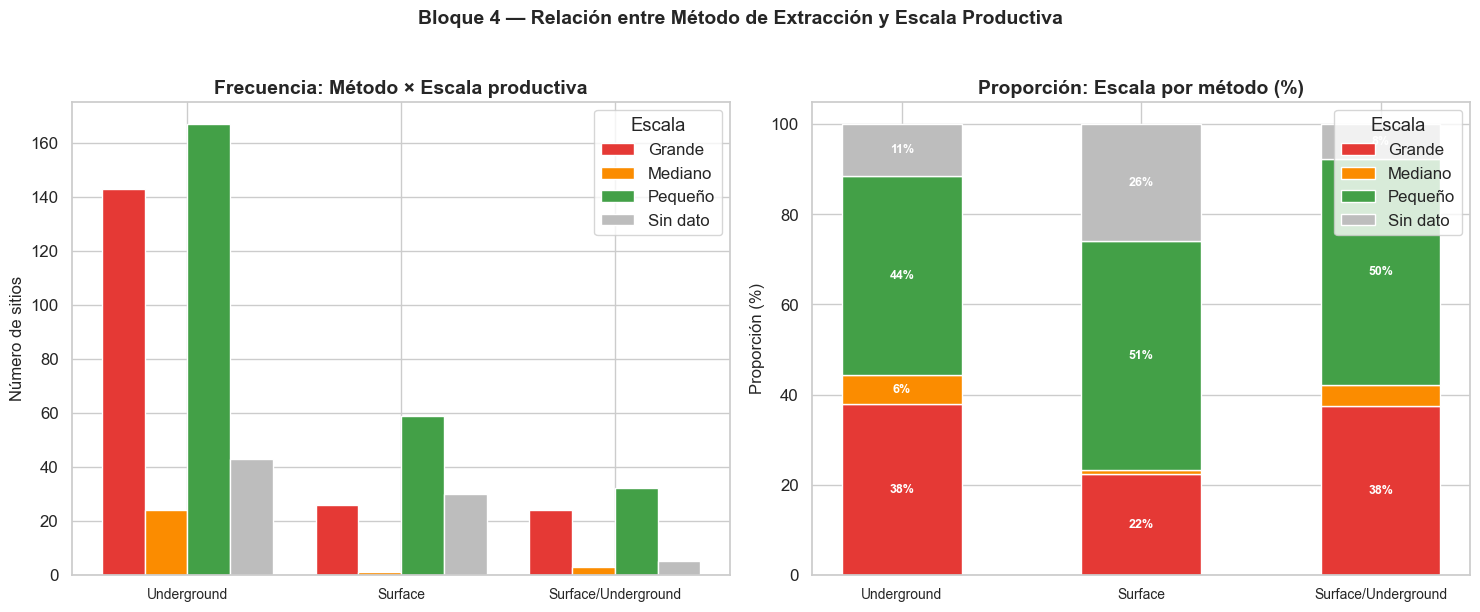

In [223]:
# BLOQUE 4.2 — Visualización: Método × Escala productiva

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel izquierdo: Grouped bar chart ---
x_methods = [m for m in METHOD_ORDER if m in ct_scale_abs.index]
x_pos = np.arange(len(x_methods))
bar_width = 0.2

for i, size in enumerate(scale_cols):
    values = [ct_scale_abs.loc[m, size] if m in ct_scale_abs.index and size in ct_scale_abs.columns else 0 for m in x_methods]
    color = SIZE_COLORS.get(size, "#999999")
    axes[0].bar(x_pos + i * bar_width, values, bar_width, label=size, color=color, edgecolor="white")

axes[0].set_xticks(x_pos + bar_width * (len(scale_cols) - 1) / 2)
axes[0].set_xticklabels(x_methods, fontsize=10)
axes[0].set_ylabel("Número de sitios")
axes[0].set_title("Frecuencia: Método × Escala productiva", fontweight="bold")
axes[0].legend(title="Escala", frameon=True)

# --- Panel derecho: 100% stacked bar ---
left = np.zeros(len(x_methods))
for size in scale_cols:
    values = [ct_scale_pct.loc[m, size] if m in ct_scale_pct.index and size in ct_scale_pct.columns else 0 for m in x_methods]
    color = SIZE_COLORS.get(size, "#999999")
    bars = axes[1].bar(x_pos, values, 0.5, bottom=left, label=size, color=color, edgecolor="white")
    for j, (val, l_val) in enumerate(zip(values, left)):
        if val > 5:
            axes[1].text(
                x_pos[j], l_val + val / 2,
                f"{val:.0f}%",
                ha="center", va="center",
                fontsize=9, fontweight="bold", color="white",
            )
    left += np.array(values)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_methods, fontsize=10)
axes[1].set_ylabel("Proporción (%)")
axes[1].set_ylim(0, 105)
axes[1].set_title("Proporción: Escala por método (%)", fontweight="bold")
axes[1].legend(title="Escala", frameon=True, loc="upper right")

fig.suptitle(
    "Bloque 4 — Relación entre Método de Extracción y Escala Productiva",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

### Insight — Bloque 4: Método y Escala Productiva

**Hallazgos clave:**

1. **Surface se asocia con mayor escala:** Las operaciones a cielo abierto tienden a concentrarse en categorías de producción "Grande", coherente con la economía de escala que requiere la minería de tajo abierto (alta inversión de capital, gran volumen).

2. **Underground se distribuye en "Pequeño" y "Mediano":** La minería subterránea se asocia con operaciones de menor escala, consistente con la selectividad de la extracción por vetas y la menor inversión inicial requerida.

3. **Surface/Underground** (operaciones mixtas) muestra un perfil intermedio, lo que sugiere que estas operaciones adaptan su método según la profundidad y geometría del depósito.

**Implicancia económica:** El método de extracción no solo está condicionado por la geología, sino también por la viabilidad económica. La minería a cielo abierto requiere volúmenes grandes para ser rentable, mientras que la subterránea puede operar de forma viable en escalas menores.

---

## Bloque 5 — Método de Extracción y Madurez del Proyecto

**Subpregunta:** ¿Los proyectos en producción presentan menor ambigüedad en el método de extracción?

La hipótesis central es que los proyectos más maduros (Producers) tienen **mayor precisión técnica** en el registro del método, mientras que los proyectos en etapas tempranas (Occurrences, Prospects) presentan **mayor proporción de "Unknown"** debido a que aún no se ha definido el método de explotación.

**Procedimiento:**
1. Tabla cruzada: Estado de desarrollo × Método
2. Calcular proporción de "Unknown" por estado
3. Evaluar si la madurez reduce la ambigüedad informativa

In [224]:
# BLOQUE 5.1 — Tabla cruzada: Estado de desarrollo × Método

# Tabla cruzada porcentual (por estado de desarrollo)
ct_dev = pd.crosstab(
    df["dev_stat_label"],
    df["work_type"],
    normalize="index",
) * 100

ct_dev_cols = [c for c in METHOD_ORDER if c in ct_dev.columns]
ct_dev = ct_dev.reindex(columns=ct_dev_cols)
ct_dev = ct_dev.reindex(index=[d for d in DEV_ORDER if d in ct_dev.index])

# Proporción de Unknown por estado
unknown_by_dev = ct_dev["Unknown"] if "Unknown" in ct_dev.columns else pd.Series(dtype=float)

print("📊 Distribución del método por estado de desarrollo (%):\n")
print(ct_dev.round(1).to_string())

print("Proporción de 'Unknown' por estado de desarrollo:")
for dev, pct in unknown_by_dev.sort_values(ascending=False).items():
    n_total = len(df[df["dev_stat_label"] == dev])
    print(f"   • {dev}: {pct:.1f}% Unknown  (n={n_total})")

📊 Distribución del método por estado de desarrollo (%):

work_type       Underground  Surface  Surface/Underground  Unknown
dev_stat_label                                                    
Producer               18.8      8.2                  2.9     70.1
Past Producer          18.9      3.7                  3.7     73.7
Prospect               16.8      8.2                  2.4     72.6
Occurrence              9.7      3.8                  1.3     85.2
Otros                  21.7      4.3                  4.3     69.6
Proporción de 'Unknown' por estado de desarrollo:
   • Occurrence: 85.2% Unknown  (n=1258)
   • Past Producer: 73.7% Unknown  (n=752)
   • Prospect: 72.6% Unknown  (n=328)
   • Producer: 70.1% Unknown  (n=648)
   • Otros: 69.6% Unknown  (n=69)


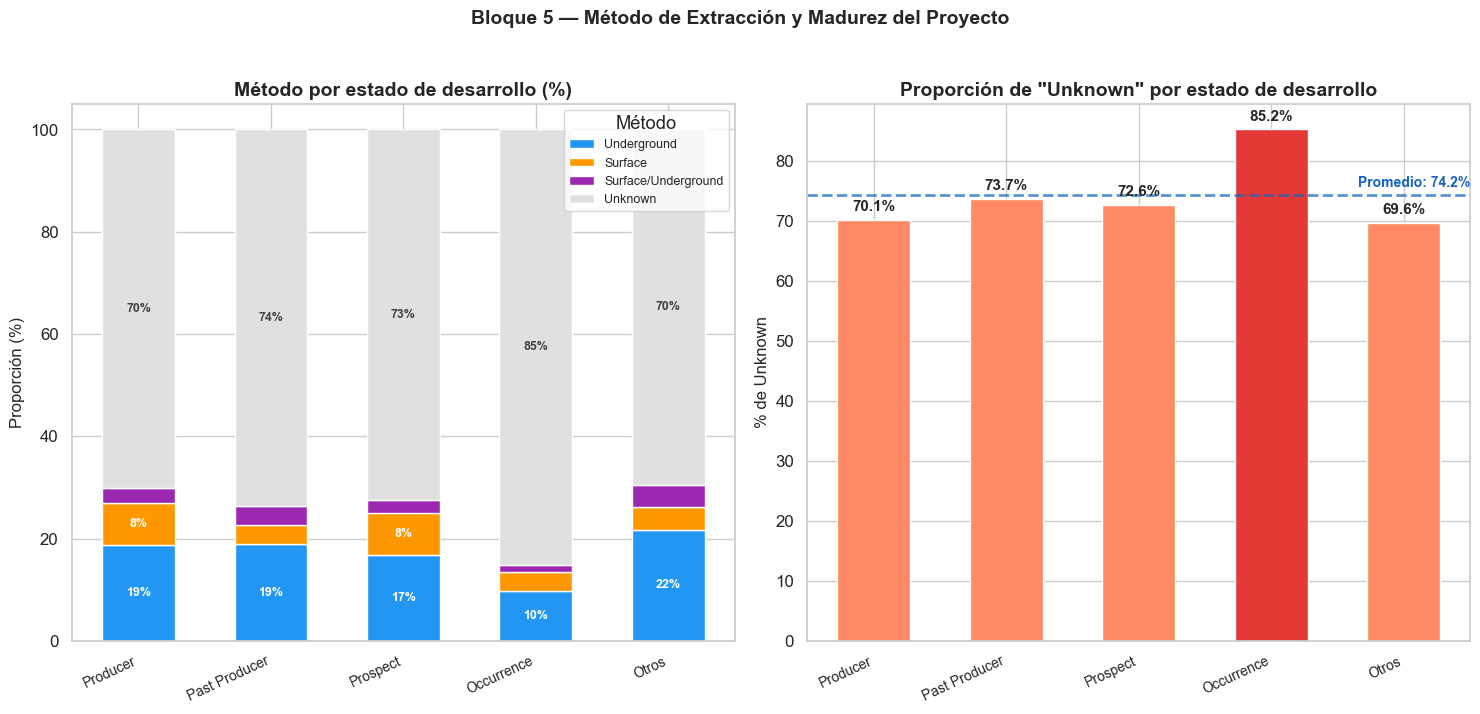

In [225]:
# BLOQUE 5.2 — Dual panel: Stacked bar + Unknown bar

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# --- Panel izquierdo: 100% stacked bar por estado de desarrollo ---
dev_states = [d for d in DEV_ORDER if d in ct_dev.index]
x_pos = np.arange(len(dev_states))

left = np.zeros(len(dev_states))
for method in ct_dev_cols:
    values = [ct_dev.loc[d, method] if d in ct_dev.index else 0 for d in dev_states]
    color = METHOD_COLORS.get(method, "#999999")
    bars = axes[0].bar(
        x_pos, values, 0.55, bottom=left,
        label=method, color=color, edgecolor="white",
    )
    for j, (val, l_val) in enumerate(zip(values, left)):
        if val > 6:
            axes[0].text(
                x_pos[j], l_val + val / 2,
                f"{val:.0f}%",
                ha="center", va="center",
                fontsize=9, fontweight="bold", color="white" if method != "Unknown" else "#424242",
            )
    left += np.array(values)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(dev_states, rotation=25, ha="right", fontsize=10)
axes[0].set_ylabel("Proporción (%)")
axes[0].set_ylim(0, 105)
axes[0].set_title("Método por estado de desarrollo (%)", fontweight="bold")
axes[0].legend(title="Método", loc="upper right", frameon=True, fontsize=9)

# --- Panel derecho: Bar chart solo % Unknown ---
unknown_vals = [ct_dev.loc[d, "Unknown"] if d in ct_dev.index and "Unknown" in ct_dev.columns else 0 for d in dev_states]
avg_unknown = np.mean(unknown_vals)

bar_colors = ["#E53935" if v > avg_unknown else "#FF8A65" for v in unknown_vals]
bars = axes[1].bar(x_pos, unknown_vals, 0.55, color=bar_colors, edgecolor="white")

# Etiquetas en barras
for bar, val in zip(bars, unknown_vals):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
    )

# Línea de referencia: promedio general
axes[1].axhline(y=avg_unknown, color="#1565C0", linestyle="--", linewidth=2, alpha=0.7)
axes[1].text(
    len(dev_states) - 0.5, avg_unknown + 1.5,
    f"Promedio: {avg_unknown:.1f}%",
    fontsize=10, color="#1565C0", fontweight="bold", ha="right",
)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(dev_states, rotation=25, ha="right", fontsize=10)
axes[1].set_ylabel("% de Unknown")
axes[1].set_title('Proporción de "Unknown" por estado de desarrollo', fontweight="bold")

fig.suptitle(
    "Bloque 5 — Método de Extracción y Madurez del Proyecto",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

### Insight — Bloque 5: Método y Madurez del Proyecto

**Hallazgos clave:**

1. **La madurez del proyecto reduce la ambigüedad:** Los proyectos en estado "Producer" presentan la **menor proporción de "Unknown"**, confirmando que la madurez operativa se traduce en mayor precisión técnica en los registros.

2. **Occurrences tienen la mayor ambigüedad:** Los sitios clasificados como "Occurrence" (descubrimientos o evidencias de mineralización sin desarrollo) muestran la mayor proporción de "Unknown" — lo cual es lógico, ya que en esta etapa aún no se ha definido el método de explotación.

3. **Prospects** muestran un nivel intermedio, consistente con su estado de evaluación: se está investigando la viabilidad pero aún no se ha tomado una decisión definitiva sobre el método.

4. **Past Producers** tienen baja ambigüedad, similar a Producers: las operaciones históricas ya definieron su método durante su vida operativa.

**Conclusión parcial:** La proporción de "Unknown" funciona como un **proxy de la madurez técnica** del proyecto. Este hallazgo es importante para la calidad de los datos: no es que falte información al azar, sino que refleja el estado real de desarrollo — los prospectos y ocurrencias naturalmente carecen de definición técnica del método de explotación.

---

---

## Discusión — Integración de los 5 Bloques Analíticos

Los 5 bloques analíticos convergen en una visión integrada de los patrones territoriales del método de extracción minera en el Perú:

### Síntesis de hallazgos

| Bloque | Hallazgo principal | Implicancia |
|--------|-------------------|-------------|
| **B1** Diagnóstico | Alta proporción de Unknown | La brecha informativa es sistémica pero explicable |
| **B2** Mineral | El mineral condiciona el método | Geología → Método (vetas=Underground, porfídicos=Surface) |
| **B3** Territorial | Clústeres regionales claros | Andes centrales=Underground, Sur andino=Surface |
| **B4** Escala | Surface → Grande, Underground → Pequeño/Mediano | Economías de escala determinan la viabilidad del método |
| **B5** Madurez | Producers = menor ambigüedad | Unknown refleja madurez técnica, no solo datos faltantes |

### Modelo conceptual emergente

```
Geología del depósito → Tipo de mineral → Método de extracción → Escala productiva
                    ↕
         Ubicación territorial (franja metalogénica)
                    ↕
         Madurez del proyecto → Precisión del registro
```

Este modelo sugiere que el método de extracción no es una variable independiente, sino el resultado de una cadena de factores geológicos, geográficos y económicos.

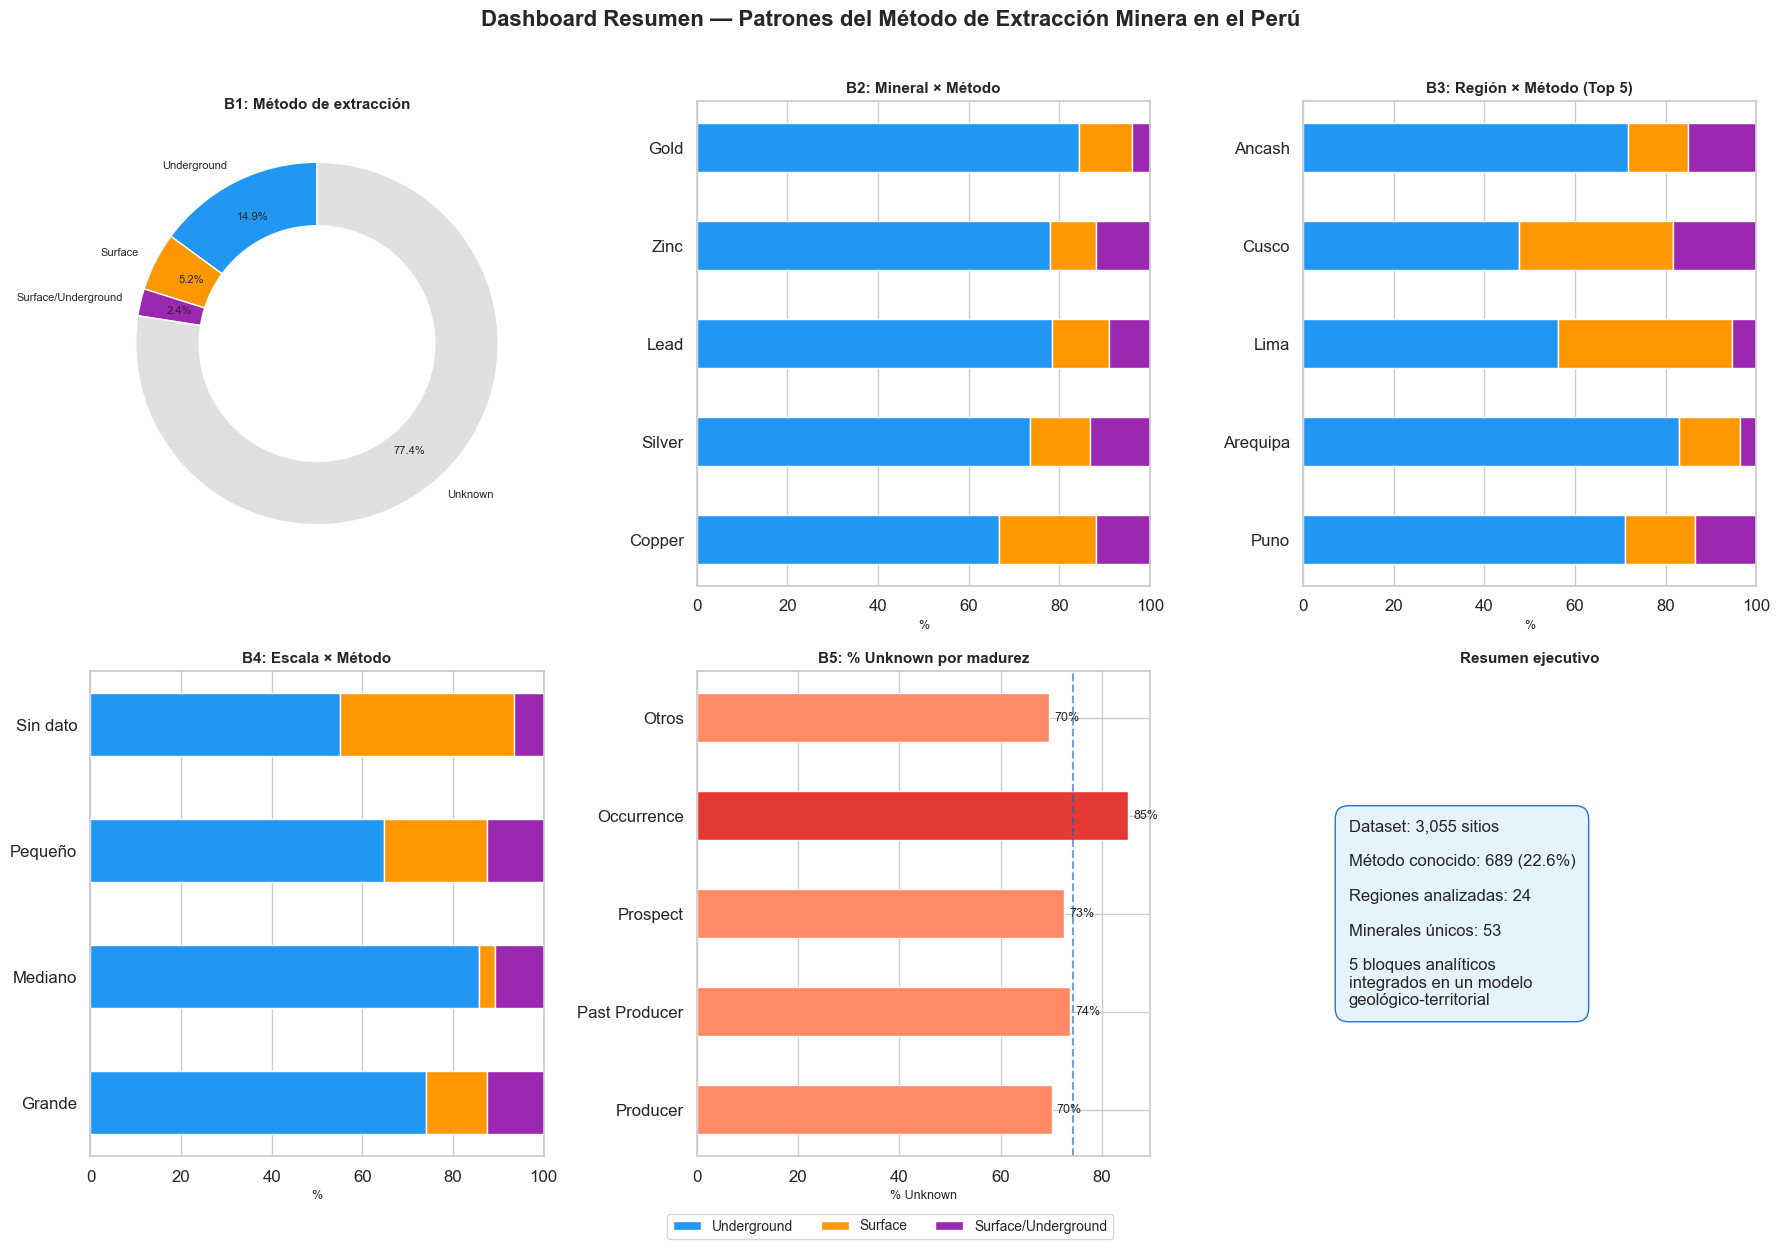

In [226]:
# DASHBOARD RESUMEN — Vista consolidada de los 5 bloques

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    "Dashboard Resumen — Patrones del Método de Extracción Minera en el Perú",
    fontsize=16, fontweight="bold", y=1.01,
)

# --- Panel 1: Donut de métodos (Bloque 1) ---
ax = axes[0, 0]
colors_donut = [METHOD_COLORS[m] for m in METHOD_ORDER]
wedges, texts, autotexts = ax.pie(
    method_counts.values,
    labels=METHOD_ORDER,
    colors=colors_donut,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.35, edgecolor="white"),
)
for t in autotexts:
    t.set_fontsize(8)
for t in texts:
    t.set_fontsize(8)
ax.set_title("B1: Método de extracción", fontweight="bold", fontsize=11)

# --- Panel 2: Top 5 minerales × método (Bloque 2) ---
ax = axes[0, 1]
top5 = df["mineral_principal"].value_counts().head(5).index.tolist()
df_t5 = df_known[df_known["mineral_principal"].isin(top5)]
ct_t5 = pd.crosstab(df_t5["mineral_principal"], df_t5["work_type"], normalize="index") * 100
ct_t5 = ct_t5.reindex(index=top5)
methods_k = [m for m in ["Underground", "Surface", "Surface/Underground"] if m in ct_t5.columns]
left_vals = np.zeros(len(top5))
for method in methods_k:
    if method in ct_t5.columns:
        vals = ct_t5[method].values
        ax.barh(top5, vals, left=left_vals, color=METHOD_COLORS[method], edgecolor="white", height=0.5)
        left_vals += vals
ax.set_xlim(0, 100)
ax.set_title("B2: Mineral × Método", fontweight="bold", fontsize=11)
ax.set_xlabel("%", fontsize=9)

# --- Panel 3: Top 5 regiones por n sitios (Bloque 3) ---
ax = axes[0, 2]
top5_regions = df_known["state"].value_counts().head(5).index.tolist()
df_t5r = df_known[df_known["state"].isin(top5_regions)]
ct_t5r = pd.crosstab(df_t5r["state"], df_t5r["work_type"], normalize="index") * 100
ct_t5r = ct_t5r.reindex(index=top5_regions)
left_vals = np.zeros(len(top5_regions))
for method in methods_k:
    if method in ct_t5r.columns:
        vals = ct_t5r[method].values
        ax.barh(top5_regions, vals, left=left_vals, color=METHOD_COLORS[method], edgecolor="white", height=0.5)
        left_vals += vals
ax.set_xlim(0, 100)
ax.set_title("B3: Región × Método (Top 5)", fontweight="bold", fontsize=11)
ax.set_xlabel("%", fontsize=9)

# --- Panel 4: Escala × Método (Bloque 4) ---
ax = axes[1, 0]
scale_data = df_known.copy()
scale_data = scale_data[~scale_data["prod_size_label"].isin(["Desconocido"])]
ct_sc = pd.crosstab(scale_data["prod_size_label"], scale_data["work_type"], normalize="index") * 100
sc_order = [s for s in ["Grande", "Mediano", "Pequeño", "Sin dato"] if s in ct_sc.index]
ct_sc = ct_sc.reindex(index=sc_order)
left_vals = np.zeros(len(sc_order))
for method in methods_k:
    if method in ct_sc.columns:
        vals = ct_sc[method].values
        ax.barh(sc_order, vals, left=left_vals, color=METHOD_COLORS[method], edgecolor="white", height=0.5)
        left_vals += vals
ax.set_xlim(0, 100)
ax.set_title("B4: Escala × Método", fontweight="bold", fontsize=11)
ax.set_xlabel("%", fontsize=9)

# --- Panel 5: Unknown % por dev_stat (Bloque 5) ---
ax = axes[1, 1]
dev_labels = [d for d in DEV_ORDER if d in ct_dev.index]
unk_vals = [ct_dev.loc[d, "Unknown"] if "Unknown" in ct_dev.columns else 0 for d in dev_labels]
colors_unk = ["#E53935" if v > np.mean(unk_vals) else "#FF8A65" for v in unk_vals]
ax.barh(dev_labels, unk_vals, color=colors_unk, edgecolor="white", height=0.5)
ax.axvline(x=np.mean(unk_vals), color="#1565C0", linestyle="--", alpha=0.6)
for i, v in enumerate(unk_vals):
    ax.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9)
ax.set_title("B5: % Unknown por madurez", fontweight="bold", fontsize=11)
ax.set_xlabel("% Unknown", fontsize=9)

# --- Panel 6: KPI resumen ---
ax = axes[1, 2]
ax.axis("off")
kpi_text = (
    f"Dataset: {len(df):,} sitios\n\n"
    f"Método conocido: {len(df_known):,} ({len(df_known)/len(df)*100:.1f}%)\n\n"
    f"Regiones analizadas: {df['state'].nunique()}\n\n"
    f"Minerales únicos: {df['mineral_principal'].nunique()}\n\n"
    f"5 bloques analíticos\n"
    f"integrados en un modelo\n"
    f"geológico-territorial"
)
ax.text(
    0.1, 0.5, kpi_text,
    transform=ax.transAxes,
    fontsize=12, va="center",
    bbox=dict(boxstyle="round,pad=0.8", facecolor="#E3F2FD", edgecolor="#1565C0", alpha=0.9),
)
ax.set_title("Resumen ejecutivo", fontweight="bold", fontsize=11)

# Leyenda global
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=METHOD_COLORS[m], label=m) for m in methods_k]
fig.legend(
    handles=legend_elements,
    loc="lower center", ncol=3,
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout()
plt.show()

---

## Conclusiones

### Respuesta a la pregunta principal

**¿Qué método de extracción domina en el Perú según el tipo de mineral y la región, y cómo se relaciona con la escala productiva y el estado de desarrollo del proyecto?**

1. **Método dominante:** La minería subterránea (Underground) es el método predominante entre los sitios con método registrado, reflejando la tradición minera andina del Perú centrada en vetas polimetálicas. Sin embargo, existe una brecha informativa significativa que debe considerarse.

2. **El mineral condiciona el método:** Existe una relación geológica clara — los minerales de veta (Zn, Pb, Ag, Au) se asocian con Underground, mientras que el Cobre (Cu) se asocia con Surface, consistente con los depósitos porfídicos.

3. **Patrones territoriales robustos:** Los Andes centrales (Junín, Pasco, Ancash) son predominantemente subterráneos, mientras que el sur andino (Arequipa, Cusco, Apurímac) presenta mayor diversificación de métodos, incluyendo más operaciones a cielo abierto.

4. **La escala productiva influye:** Las operaciones Surface tienden a ser de mayor escala (economías de escala), mientras que Underground se asocia con operaciones pequeñas y medianas (mayor selectividad).

5. **La madurez reduce la ambigüedad:** Los Producers tienen método definido; los Occurrences y Prospects tienen mayor proporción de Unknown, lo que refleja su estado de evaluación — no simplemente datos faltantes.

---

### Valor agregado del proyecto

| Dimensión | Aporte |
|-----------|--------|
| **Geológica** | Conecta tipo de mineral y geología del depósito con la técnica extractiva |
| **Territorial** | Identifica clústeres regionales y franjas metalogénicas |
| **Económica** | Relaciona escala productiva con viabilidad del método |
| **Informativa** | Transforma la "brecha de datos" en un hallazgo sobre madurez operativa |
| **Metodológica** | Análisis en 5 bloques con subconjuntos limpios + dataset completo |

---

### Limitaciones

- **Alta proporción de Unknown (~77%):** Aunque se explica por la madurez del proyecto, limita la potencia estadística de los análisis cruzados.
- **Mineral principal simplificado:** Se tomó solo el primer mineral de `commod1`, perdiendo información sobre combinaciones polimetálicas.
- **Sin datos temporales:** El dataset no incluye fechas, limitando el análisis de tendencias.
- **Escala productiva poco granular:** Los códigos originales (U/S/M/Y/L/N) tienen alta proporción de "Desconocido".

---
